In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
text = "The product is not good but the delivery serviced is very fast"

In [ ]:
nltk.download('punkt_tab')
tokens = word_tokenize(text.lower())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
bigrams = list(ngrams(tokens,2))

In [ ]:
print("Bigrams:")
for bg in bigrams:
  print(bg)

Bigrams:
('the', 'product')
('product', 'is')
('is', 'not')
('not', 'good')
('good', 'but')
('but', 'the')
('the', 'delivery')
('delivery', 'serviced')
('serviced', 'is')
('is', 'very')
('very', 'fast')


In [ ]:
# define sentiment bigrams
positive_bigrams = [('very', 'product'), ('very', 'fast')],["good","service"]
negative_bigrams = [('not','good'),('very','bad'),('poor','service')]

In [ ]:
# sentiment detection
positive_count = 0
negative_bigrams = 0

In [ ]:
positive_bigrams_list = [('very', 'product'), ('very', 'fast'), ('good', 'service')]
negative_bigrams_list = [('not','good'),('very','bad'),('poor','service')]

# Re-initialize counters if they might have been misused/overwritten
positive_count = 0
negative_count = 0

for bg in bigrams:
  if bg in positive_bigrams_list:
    positive_count +=1
  if bg in negative_bigrams_list:
    negative_count +=1

In [ ]:
print("\nPositive bigram matches:", positive_count)
print("Negative bigram matches:", negative_count)


Positive bigram matches: 1
Negative bigram matches: 1


In [ ]:
# final sentiment
if positive_count > negative_count:
  print("\nOverall Sentiment: Positive")
elif positive_count < negative_count:
  print("\nOverall Sentiment: Negative")
else:
  print("\n Overall Sentiment: Neutral")


 Overall Sentiment: Neutral


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
text = "The product quality is very good and the delivery service is very fast"

In [ ]:
tokens  = word_tokenize(text.lower())

In [ ]:
bigrams = list(ngrams(tokens,2))

In [ ]:
G = nx.Graph()

In [ ]:
for bg in bigrams:
  G.add_edge(bg[0],bg[1])

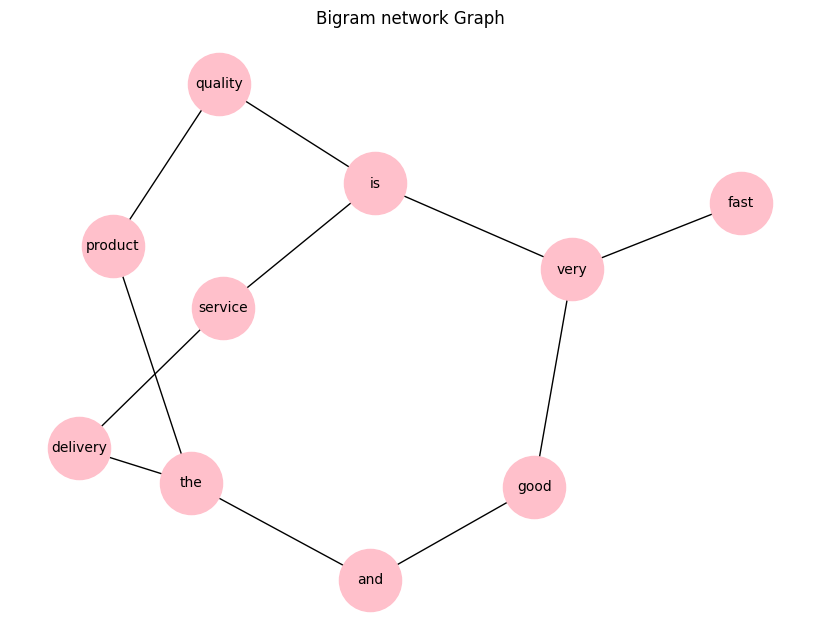

In [ ]:
plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True, node_size=2000, node_color="pink", font_size=10)
plt.title("Bigram network Graph")
plt.show()

In [ ]:
from nltk.util import ngrams
from collections import Counter

In [ ]:
text = "good product good quality proudct"
tokens = text.split()

In [ ]:
#generate bigrams
bigrams = list(ngrams(tokens,2))

In [ ]:
#Count frequency
freq = Counter(bigrams)
print(freq)

Counter({('good', 'product'): 1, ('product', 'good'): 1, ('good', 'quality'): 1, ('quality', 'proudct'): 1})


In [ ]:
import math

In [ ]:
tokens = text.split()

In [ ]:
total_words = len(tokens)

In [ ]:
word_counts = Counter(tokens)

In [ ]:
bigram_counts = Counter(ngrams(tokens,2))

In [ ]:
def pmi(w1,w2):
  p_w1 = word_counts[w1]/total_words
  p_w2 = word_counts[w2]/total_words
  p_w1_w2 = bigram_counts[(w1,w2)]/total_words

  return math.log2(p_w1_w2/(p_w1*p_w2))

In [ ]:
print(pmi('good','product'))

1.3219280948873622


In [ ]:
#STEP 1 : SAMPLE DS
reviews = [
    "This product is amazing! It exceeded my expectations.",
    "I'm blown away by the quality of this product.",
    "This is the best product",
    "Worst product not good at all",
    "Very bad quality not recommended at all",
    "Highly recommended this amazing product",
    "Best product best price highly recommended",
    "Not good not worth money"
]

In [ ]:
import re

def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-z\s]','', text)
  return text

cleaned_reviews = [clean_text(r)for r in reviews]

In [ ]:
#GENERATE BIGRAMS
from nltk.util import ngrams


In [ ]:
all_bigrams = []
for review in cleaned_reviews:
  tokens = review.split()
  bigrams = list(ngrams(tokens,2))
  all_bigrams.extend(bigrams)

In [ ]:
from collections import Counter

In [ ]:
bigram_freq = Counter(all_bigrams)

In [ ]:
print("Top Word Pairs:")
for pair, count in bigram_freq.most_common(10):
  print(pair,":",count)

Top Word Pairs:
('this', 'product') : 2
('best', 'product') : 2
('not', 'good') : 2
('at', 'all') : 2
('highly', 'recommended') : 2
('product', 'is') : 1
('is', 'amazing') : 1
('amazing', 'it') : 1
('it', 'exceeded') : 1
('exceeded', 'my') : 1


In [ ]:
#Count individual words
all_words = "".join(cleaned_reviews).split()
word_freq = Counter(all_words)

In [ ]:
total_words = len(all_words)
total_bigrams = len(all_bigrams)

In [ ]:
def compute_pmi(w1,w2):
  # Use the correct frequency counters based on cleaned_reviews
  p_w1 = word_freq[w1]/total_words
  p_w2 = word_freq[w2]/total_words
  p_w1_w2 = bigram_freq[(w1,w2)]/total_bigrams

  # Check for division by zero to prevent errors
  denominator = p_w1 * p_w2
  if denominator == 0:
    return 0.0 # Return 0 for undefined PMI to avoid crash

  return math.log2(p_w1_w2/denominator)

In [ ]:
print('\nPMI Scores:')
for pair in bigram_freq:
  print(pair,":",round(compute_pmi(pair[0],pair[1]),2))


PMI Scores:
('this', 'product') : 3.32
('product', 'is') : 2.91
('is', 'amazing') : 3.49
('amazing', 'it') : 4.49
('it', 'exceeded') : 5.49
('exceeded', 'my') : 5.49
('my', 'expectations') : 0.0
('im', 'blown') : 0.0
('blown', 'away') : 5.49
('away', 'by') : 5.49
('by', 'the') : 4.49
('the', 'quality') : 3.49
('quality', 'of') : 4.49
('of', 'this') : 3.91
('this', 'is') : 2.91
('is', 'the') : 3.49
('the', 'best') : 3.49
('best', 'product') : 3.91
('worst', 'product') : 0.0
('product', 'not') : 2.32
('not', 'good') : 3.91
('good', 'at') : 3.49
('at', 'all') : 0.0
('very', 'bad') : 0.0
('bad', 'quality') : 4.49
('quality', 'not') : 2.91
('not', 'recommended') : 2.91
('recommended', 'at') : 3.49
('highly', 'recommended') : 5.49
('recommended', 'this') : 2.91
('this', 'amazing') : 2.91
('amazing', 'product') : 2.91
('product', 'best') : 2.91
('best', 'price') : 4.49
('price', 'highly') : 5.49
('good', 'not') : 2.91
('not', 'worth') : 3.91
('worth', 'money') : 5.49


In [ ]:
suspicious_pairs = []
for pair , count in bigram_freq.items():
  if count > 2:
    pmi_score = compute_pmi(pair[0],pair[1])
    if pmi_score >1:
      suspicious_pairs.append((pair,count,round(pmi_score,2)))


In [ ]:
print("\nSuspicious Pairs:")
for item in suspicious_pairs:
  print(item)


Suspicious Pairs:
